# Simulation Audit

This notebook audits whether the generated BBH simulation dataset contains learnable information.

The goal is to check, before generating additional datasets, whether:

1. the HDF5 file is internally consistent;
2. labels match the physical parameters;
3. the input strain contains non-trivial sample-to-sample information;
4. simple features correlate with physical parameters;
5. the processed strain is not dominated by artifacts;
6. a simple model can learn something above a trivial baseline;
7. a CNN can overfit a tiny subset.

If these checks fail, the issue is likely in the simulation, preprocessing, data loading, or training setup rather than in the final model architecture.

In [1]:
from pathlib import Path
import json
import h5py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATASET_PATH = Path("/scratch/vserrano/cbc_pe_data/processed/bbh_32s_m1-xx_m2-xx_n100/bbh_processed_32s_m1-20_m2-20_n100_01.h5")

assert DATASET_PATH.exists(), DATASET_PATH

DATASET_PATH

PosixPath('/scratch/vserrano/cbc_pe_data/processed/bbh_32s_m1-xx_m2-xx_n100/bbh_processed_32s_m1-20_m2-20_n100_01.h5')

## 1. Basic HDF5 structure

We first inspect the file structure, shapes, attributes, and basic numerical validity.

This does not prove that the simulations are learnable, but it rules out obvious storage problems.

In [3]:
with h5py.File(DATASET_PATH, "r") as f:
    print("keys:", list(f.keys()))
    print("attrs:")
    for key, value in f.attrs.items():
        print(f"  {key}: {value}")

    print()
    print("X shape:", f["X"].shape)
    print("y shape:", f["y"].shape)

    print()
    print("groups:")
    for key in f.keys():
        obj = f[key]
        if isinstance(obj, h5py.Group):
            print(f"  {key}/ -> {list(obj.keys())}")
        else:
            print(f"  {key} -> shape={obj.shape}, dtype={obj.dtype}")

keys: ['X', 'generation', 'injection', 'parameters', 'snr', 'y']
attrs:
  chunk_size: 100
  dataset_status: complete
  detector_names: ["H1", "L1", "V1"]
  duration: 32.0
  label_names: ["chirp_mass", "total_mass", "chi_eff"]
  length: 131072
  low_frequency_cutoff: 30.0
  num_samples: 100
  num_written: 100
  placement_policy: random_contained
  processing_context_end_samples: 1664
  processing_context_start_samples: 1664
  processing_length: 134400
  sampling_frequency: 4096.0
  seed: 2000
  signal_processor_config: {"whitening_method": "psd", "apply_highpass": true, "apply_lowpass": true, "apply_standardization": false, "output_mode": "crop_to_config", "whitening_low_frequency_cutoff": 30.0, "whitening_max_filter_duration": 0.5, "whitening_trunc_method": "hann", "highpass_frequency": 30.0, "lowpass_frequency": 512.0, "fir_order": 256, "fir_beta": 5.0, "remove_corrupted": true}
  standardize_labels: False

X shape: (100, 3, 131072)
y shape: (100, 3)

groups:
  X -> shape=(100, 3, 131

In [4]:
with h5py.File(DATASET_PATH, "r") as f:
    X_head = f["X"][:100]
    y = f["y"][:]

    print("X finite:", np.all(np.isfinite(X_head)))
    print("y finite:", np.all(np.isfinite(y)))

    print()
    print("X mean first 100:", X_head.mean())
    print("X std first 100:", X_head.std())
    print("X min first 100:", X_head.min())
    print("X max first 100:", X_head.max())

    print()
    print("y mean:", y.mean(axis=0))
    print("y std:", y.std(axis=0))
    print("y min:", y.min(axis=0))
    print("y max:", y.max(axis=0))

X finite: True
y finite: True

X mean first 100: 3.6489764e-05
X std first 100: 21.837631
X min first 100: -153.91844
X max first 100: 174.41624

y mean: [17.41101 40.       0.     ]
y std: [0. 0. 0.]
y min: [17.41101 40.       0.     ]
y max: [17.41101 40.       0.     ]


## 2. Label consistency

The target vector should be:

`[chirp_mass, total_mass, chi_eff]`

This check verifies that the stored `y` values match the physical parameters saved in the HDF5 file.

If this fails, model training is meaningless because the inputs and labels are inconsistent.

In [5]:
with h5py.File(DATASET_PATH, "r") as f:
    y = f["y"][:]

    chirp_mass = f["parameters/chirp_mass"][:]
    total_mass = f["parameters/total_mass"][:]
    chi_eff = f["parameters/chi_eff"][:]

    y_from_params = np.stack(
        [chirp_mass, total_mass, chi_eff],
        axis=1,
    )

diff = y - y_from_params

print("max |y - y_from_params|:", np.max(np.abs(diff)))
print("mean |y - y_from_params|:", np.mean(np.abs(diff)))

assert np.allclose(y, y_from_params)

max |y - y_from_params|: 0.0
mean |y - y_from_params|: 0.0


## 3. Parameter distributions

We inspect the physical parameter distributions.

A model cannot learn regions of parameter space that are poorly represented, and a heavily skewed distribution can make global losses misleading.

In [6]:
with h5py.File(DATASET_PATH, "r") as f:
    params_df = pd.DataFrame({
        "mass_1": f["parameters/mass_1"][:],
        "mass_2": f["parameters/mass_2"][:],
        "distance": f["parameters/distance"][:],
        "chirp_mass": f["parameters/chirp_mass"][:],
        "total_mass": f["parameters/total_mass"][:],
        "chi_eff": f["parameters/chi_eff"][:],
        "network_snr": f["snr/network"][:],
    })

params_df.describe()

,mass_1,mass_2,distance,chirp_mass,total_mass,chi_eff,network_snr
count,100.0,100.0,100.000000,100.000000,100.0,100.0,100.000000
mean,20.0,20.0,983.756714,17.411011,40.0,0.0,17.124666
std,0.0,0.0,538.376648,0.000000,0.0,0.0,4.537332
min,20.0,20.0,267.904755,17.411011,40.0,0.0,10.115083
25%,20.0,20.0,621.109497,17.411011,40.0,0.0,12.906430
50%,20.0,20.0,844.881897,17.411011,40.0,0.0,17.286338
75%,20.0,20.0,1249.267517,17.411011,40.0,0.0,20.499364
max,20.0,20.0,3276.833740,17.411011,40.0,0.0,24.961651


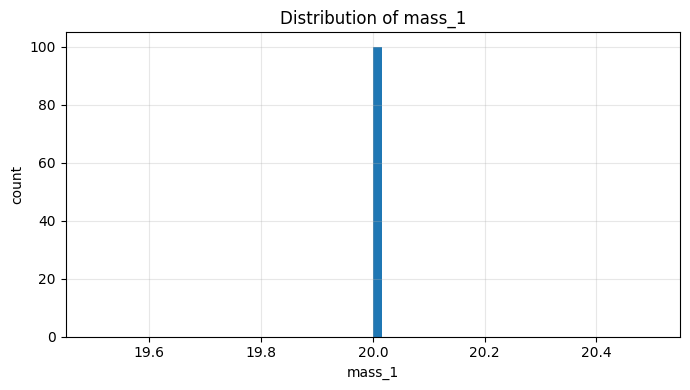

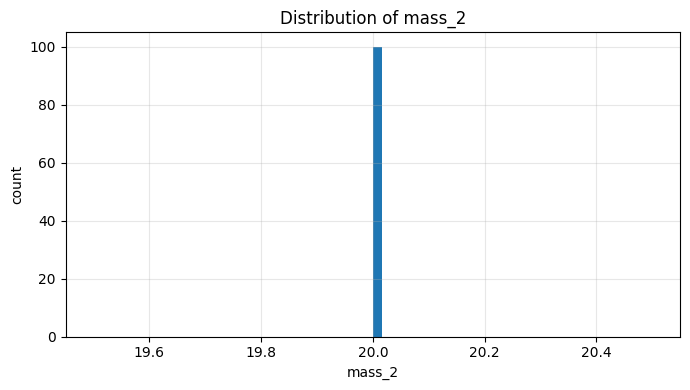

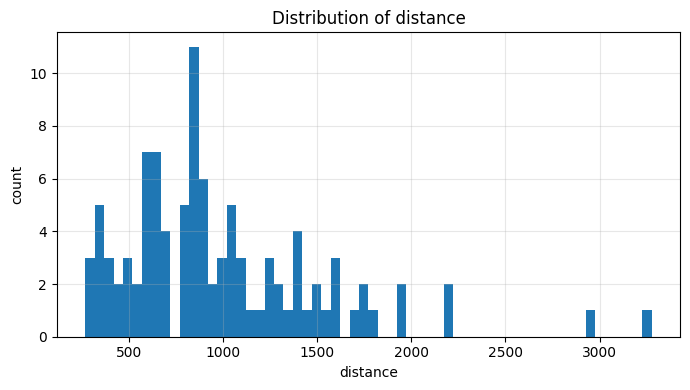

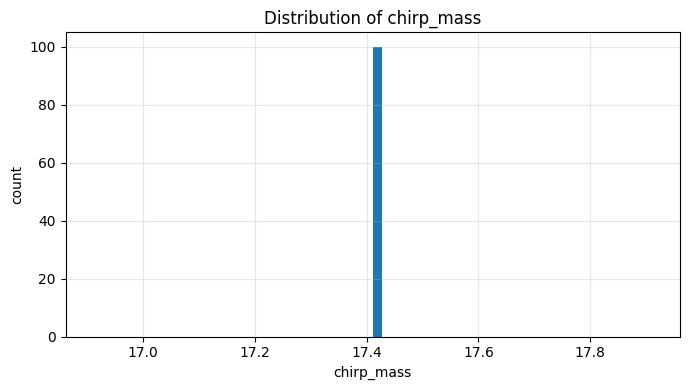

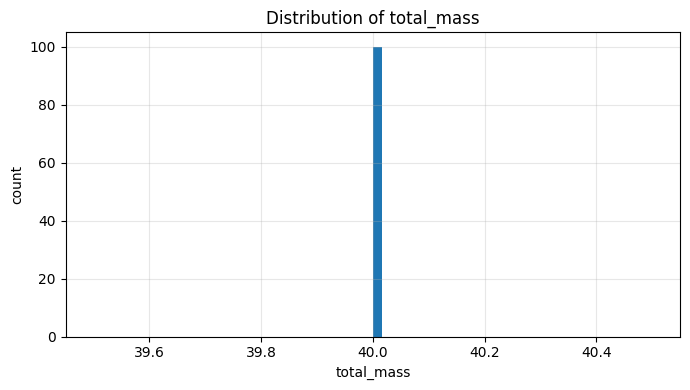

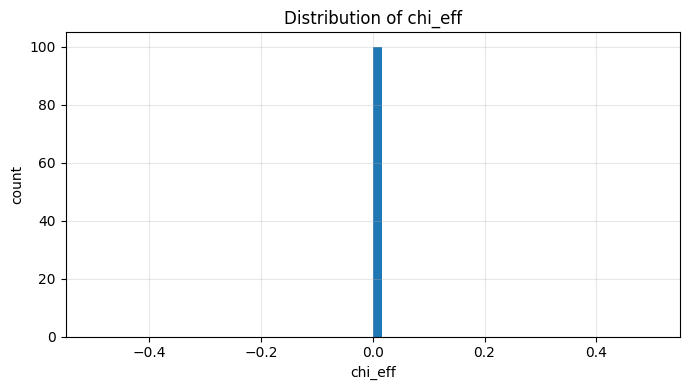

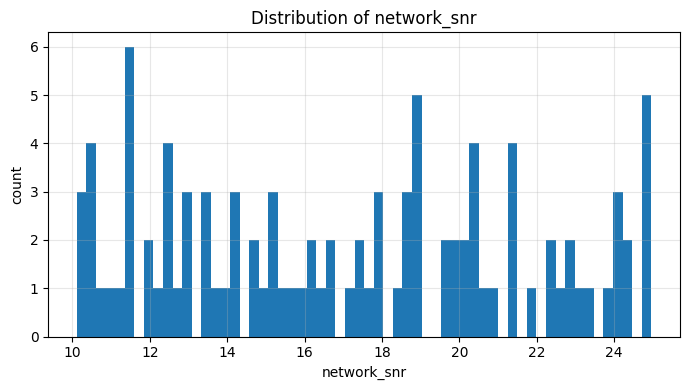

In [7]:
cols = [
    "mass_1",
    "mass_2",
    "distance",
    "chirp_mass",
    "total_mass",
    "chi_eff",
    "network_snr",
]

for col in cols:
    plt.figure(figsize=(7, 4))
    plt.hist(params_df[col], bins=60)
    plt.xlabel(col)
    plt.ylabel("count")
    plt.title(f"Distribution of {col}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pandas/plotting/_matplotlib/misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])
/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pandas/plotting/_matplotlib/misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pandas/plotting/_matplotlib/misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pandas/plotting/_matplotlib/misc.py:115: RuntimeWarning: invalid value encountered in divide
  a

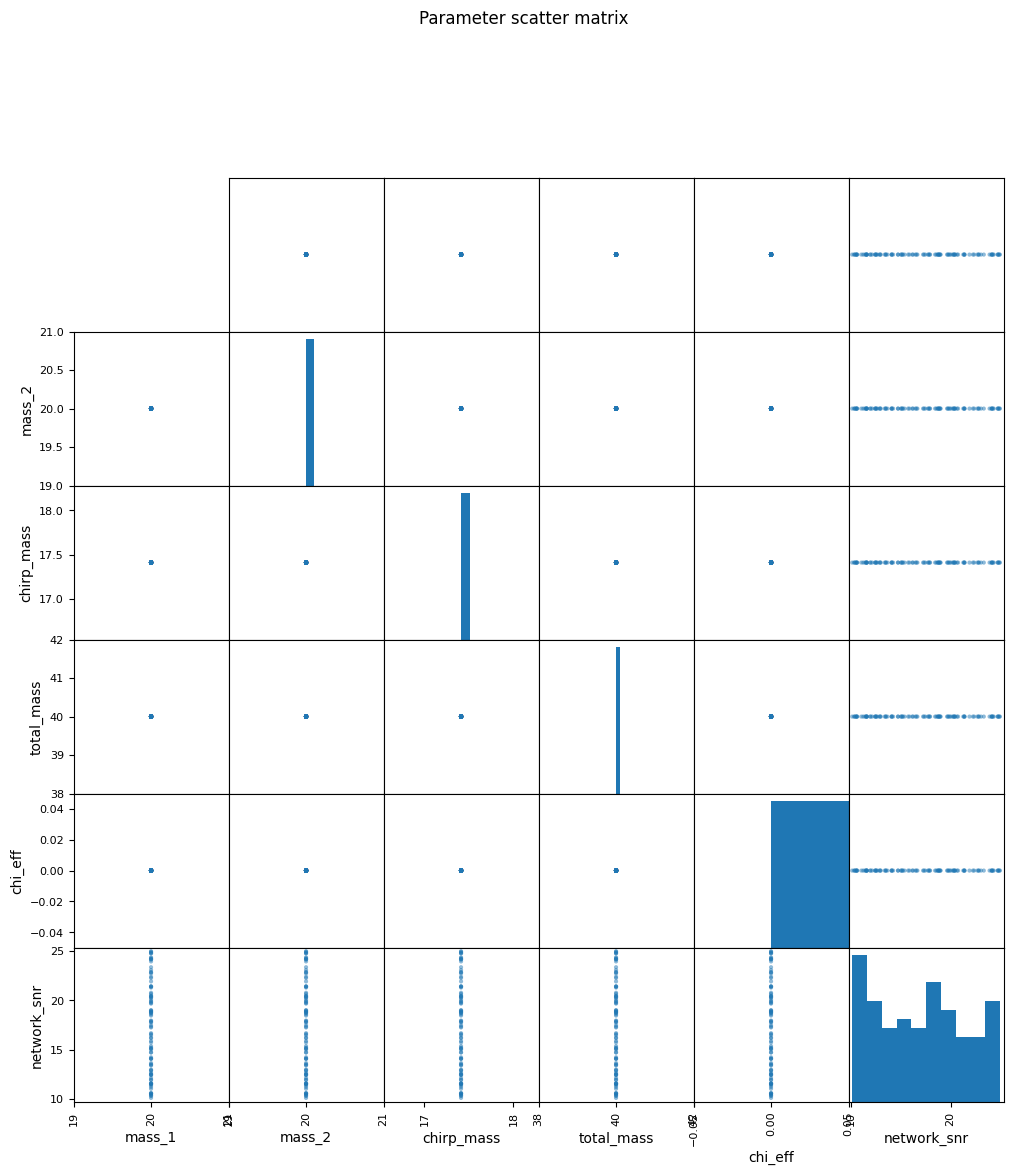

In [8]:
pd.plotting.scatter_matrix(
    params_df[["mass_1", "mass_2", "chirp_mass", "total_mass", "chi_eff", "network_snr"]].sample(
        min(5000, len(params_df)),
        random_state=123,
    ),
    figsize=(12, 12),
    diagonal="hist",
)
plt.suptitle("Parameter scatter matrix", y=1.02)
plt.show()

## 4. Sample-level strain statistics

We compute simple statistics from `X` per sample and detector.

This is not a substitute for a CNN, but it can reveal whether all samples look almost identical after preprocessing, or whether some obvious artifacts dominate the dataset.

In [9]:
def compute_x_summary(h5_path, max_samples=None, batch_size=1024):
    rows = []

    with h5py.File(h5_path, "r") as f:
        X = f["X"]
        n = X.shape[0] if max_samples is None else min(max_samples, X.shape[0])

        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            xb = X[start:end]

            # shape: (batch, detectors, time)
            mean_per_sample = xb.mean(axis=(1, 2))
            std_per_sample = xb.std(axis=(1, 2))
            max_abs_per_sample = np.max(np.abs(xb), axis=(1, 2))
            rms_per_sample = np.sqrt(np.mean(xb**2, axis=(1, 2)))

            for i in range(end - start):
                rows.append({
                    "index": start + i,
                    "x_mean": mean_per_sample[i],
                    "x_std": std_per_sample[i],
                    "x_max_abs": max_abs_per_sample[i],
                    "x_rms": rms_per_sample[i],
                })

    return pd.DataFrame(rows)


x_summary = compute_x_summary(DATASET_PATH, max_samples=20000)
x_summary.describe()

,index,x_mean,x_std,x_max_abs,x_rms
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,49.500000,0.000036,21.837580,108.625244,21.837580
std,29.011492,0.000693,0.051725,10.685257,0.051726
min,0.000000,-0.001684,21.713478,94.718269,21.713478
25%,24.750000,-0.000387,21.797055,102.404976,21.797055
50%,49.500000,0.000045,21.837498,106.556881,21.837499
75%,74.250000,0.000538,21.871701,112.865110,21.871701
max,99.000000,0.001892,21.995039,174.416245,21.995039


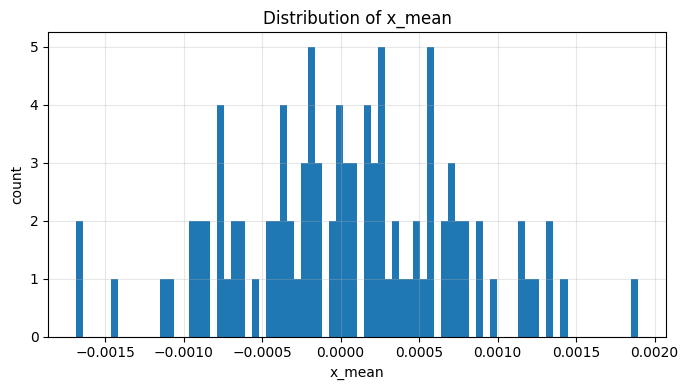

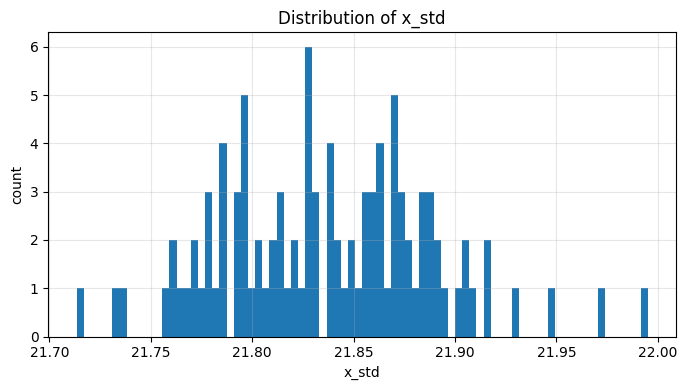

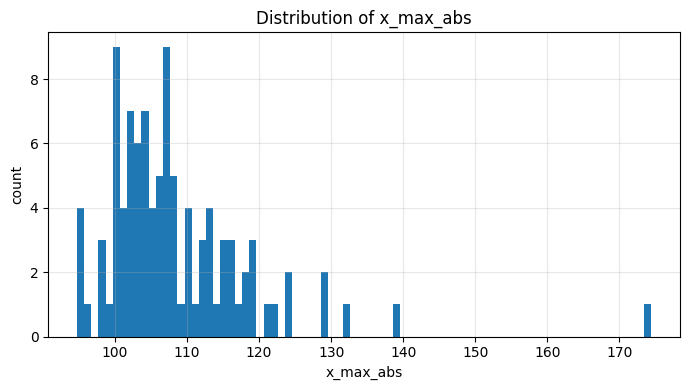

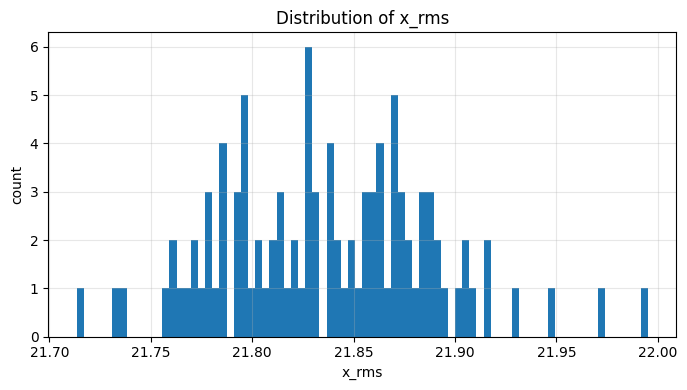

In [10]:
for col in ["x_mean", "x_std", "x_max_abs", "x_rms"]:
    plt.figure(figsize=(7, 4))
    plt.hist(x_summary[col], bins=80)
    plt.xlabel(col)
    plt.ylabel("count")
    plt.title(f"Distribution of {col}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Interpretación:

- x_std casi idéntico para todas las muestras
- x_rms casi idéntico
- x_max_abs dominado por outliers enormes

podría indicar que el procesado está normalizando o contaminando demasiado el input.

## 5. Correlation between simple strain features and labels

Before training a CNN, we check whether simple summary statistics of `X` show any relationship with the labels.

This is not expected to solve parameter estimation, but if absolutely no simple feature has any relationship with any label, it is a warning sign.

In [11]:
audit_df = x_summary.merge(
    params_df.reset_index().rename(columns={"index": "index"}),
    on="index",
    how="left",
)

corr_cols = [
    "x_mean",
    "x_std",
    "x_max_abs",
    "x_rms",
    "chirp_mass",
    "total_mass",
    "chi_eff",
    "network_snr",
    "distance",
]

corr = audit_df[corr_cols].corr()
corr

,x_mean,x_std,x_max_abs,x_rms,chirp_mass,total_mass,chi_eff,network_snr,distance
x_mean,1.000000,0.020386,-0.101721,0.020387,NaN,NaN,NaN,-0.037940,-0.031852
x_std,0.020386,1.000000,-0.004536,1.000000,NaN,NaN,NaN,0.274416,-0.107984
x_max_abs,-0.101721,-0.004536,1.000000,-0.004535,NaN,NaN,NaN,0.281155,-0.196441
x_rms,0.020387,1.000000,-0.004535,1.000000,NaN,NaN,NaN,0.274417,-0.107982
chirp_mass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_mass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chi_eff,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
network_snr,-0.037940,0.274416,0.281155,0.274417,NaN,NaN,NaN,1.000000,-0.450739
distance,-0.031852,-0.107984,-0.196441,-0.107982,NaN,NaN,NaN,-0.450739,1.000000


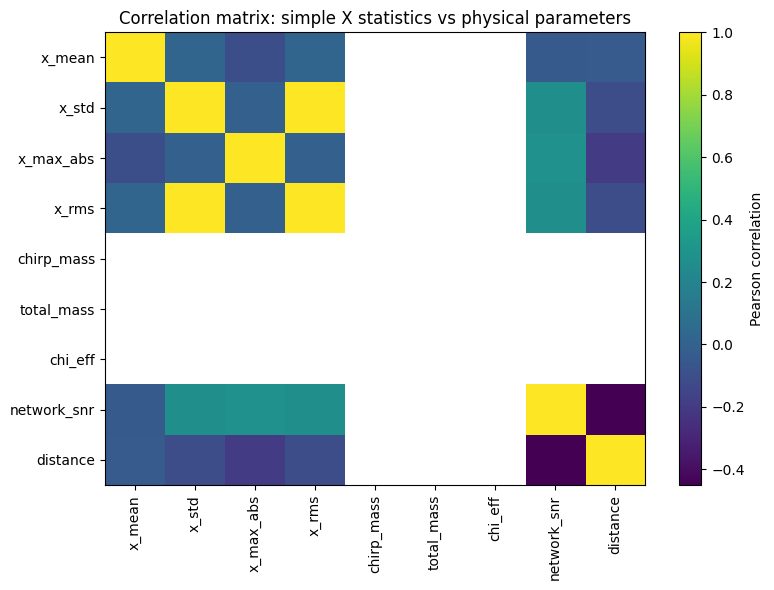

In [12]:
plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Pearson correlation")
plt.title("Correlation matrix: simple X statistics vs physical parameters")
plt.tight_layout()
plt.show()

## 6. Visual inspection of random samples

We plot random processed samples.

This helps detect obvious artifacts, suspiciously identical samples, clipping, excessive amplitudes, or preprocessing failures.

In [13]:
def plot_sample_from_hdf5(h5_path, sample_idx, detector_names=("H1", "L1", "V1")):
    with h5py.File(h5_path, "r") as f:
        x = f["X"][sample_idx]
        fs = float(f.attrs.get("sampling_frequency", 4096.0))
        y = f["y"][sample_idx]

        params = {
            "mass_1": f["parameters/mass_1"][sample_idx],
            "mass_2": f["parameters/mass_2"][sample_idx],
            "chirp_mass": f["parameters/chirp_mass"][sample_idx],
            "total_mass": f["parameters/total_mass"][sample_idx],
            "chi_eff": f["parameters/chi_eff"][sample_idx],
            "network_snr": f["snr/network"][sample_idx],
        }

    t = np.arange(x.shape[-1]) / fs

    fig, axes = plt.subplots(
        x.shape[0],
        1,
        figsize=(14, 2.8 * x.shape[0]),
        sharex=True,
    )

    if x.shape[0] == 1:
        axes = [axes]

    for det_idx in range(x.shape[0]):
        det_name = detector_names[det_idx] if det_idx < len(detector_names) else f"det{det_idx}"
        axes[det_idx].plot(t, x[det_idx], alpha=0.9)
        axes[det_idx].set_ylabel(det_name)
        axes[det_idx].grid(alpha=0.3)

    axes[-1].set_xlabel("Time [s]")

    title = (
        f"sample={sample_idx} | "
        f"m1={params['mass_1']:.1f}, m2={params['mass_2']:.1f}, "
        f"Mc={params['chirp_mass']:.1f}, Mtot={params['total_mass']:.1f}, "
        f"chi_eff={params['chi_eff']:.2f}, SNR={params['network_snr']:.1f}"
    )

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

    return params, y

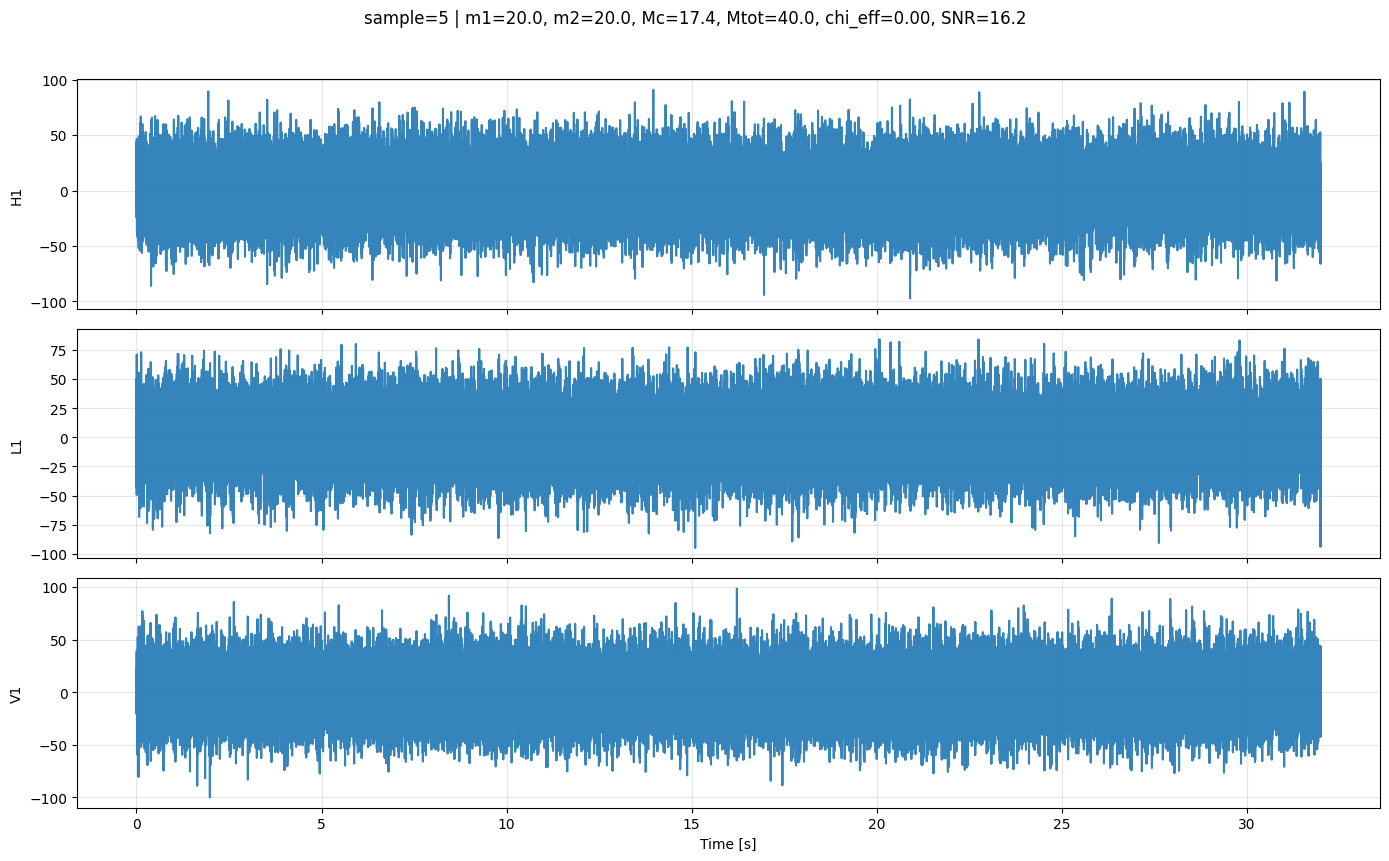

y: [17.41101 40.       0.     ]
params: {'mass_1': np.float32(20.0), 'mass_2': np.float32(20.0), 'chirp_mass': np.float32(17.41101), 'total_mass': np.float32(40.0), 'chi_eff': np.float32(0.0), 'network_snr': np.float32(16.163786)}



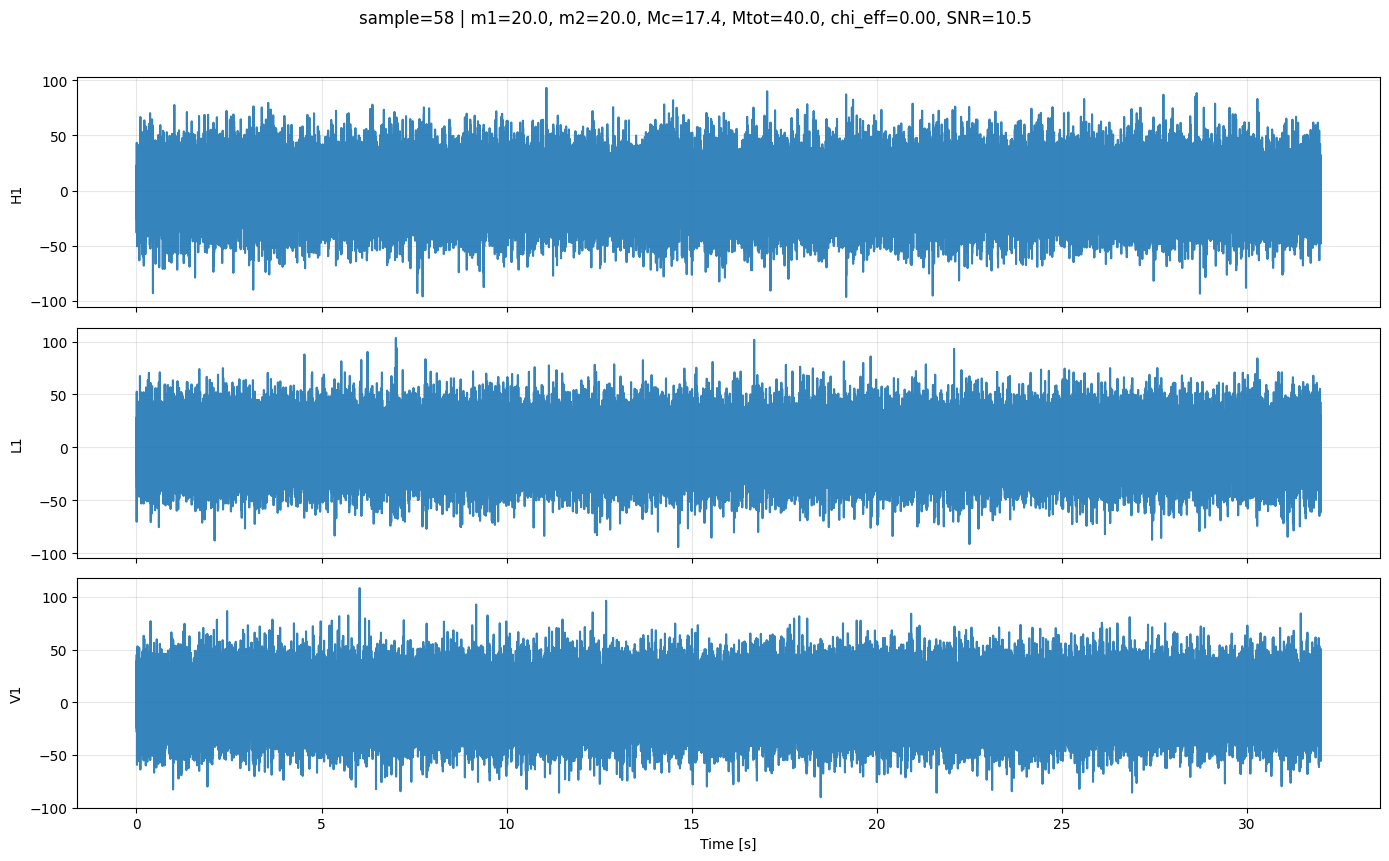

y: [17.41101 40.       0.     ]
params: {'mass_1': np.float32(20.0), 'mass_2': np.float32(20.0), 'chirp_mass': np.float32(17.41101), 'total_mass': np.float32(40.0), 'chi_eff': np.float32(0.0), 'network_snr': np.float32(10.540247)}



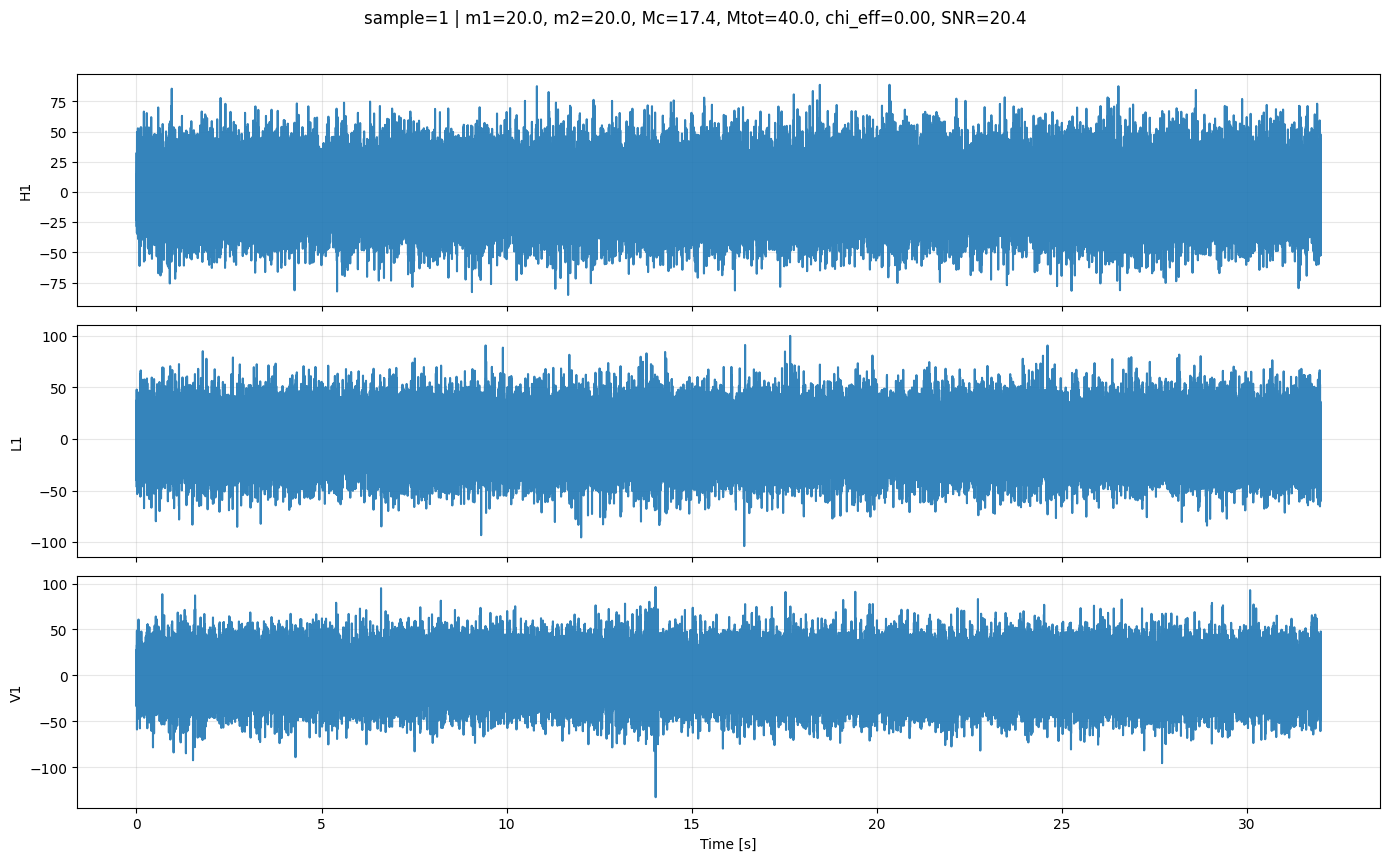

y: [17.41101 40.       0.     ]
params: {'mass_1': np.float32(20.0), 'mass_2': np.float32(20.0), 'chirp_mass': np.float32(17.41101), 'total_mass': np.float32(40.0), 'chi_eff': np.float32(0.0), 'network_snr': np.float32(20.430492)}



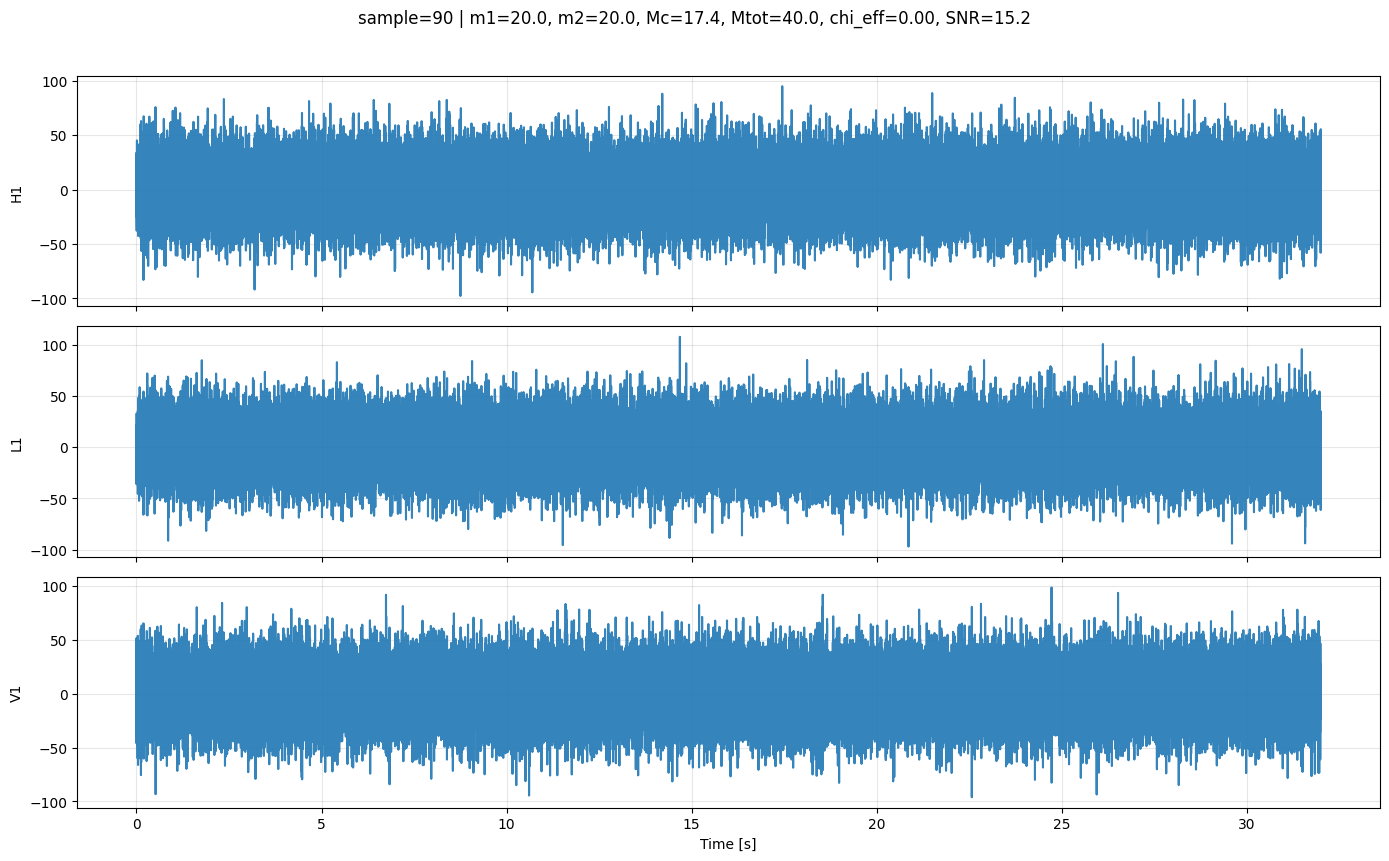

y: [17.41101 40.       0.     ]
params: {'mass_1': np.float32(20.0), 'mass_2': np.float32(20.0), 'chirp_mass': np.float32(17.41101), 'total_mass': np.float32(40.0), 'chi_eff': np.float32(0.0), 'network_snr': np.float32(15.186026)}



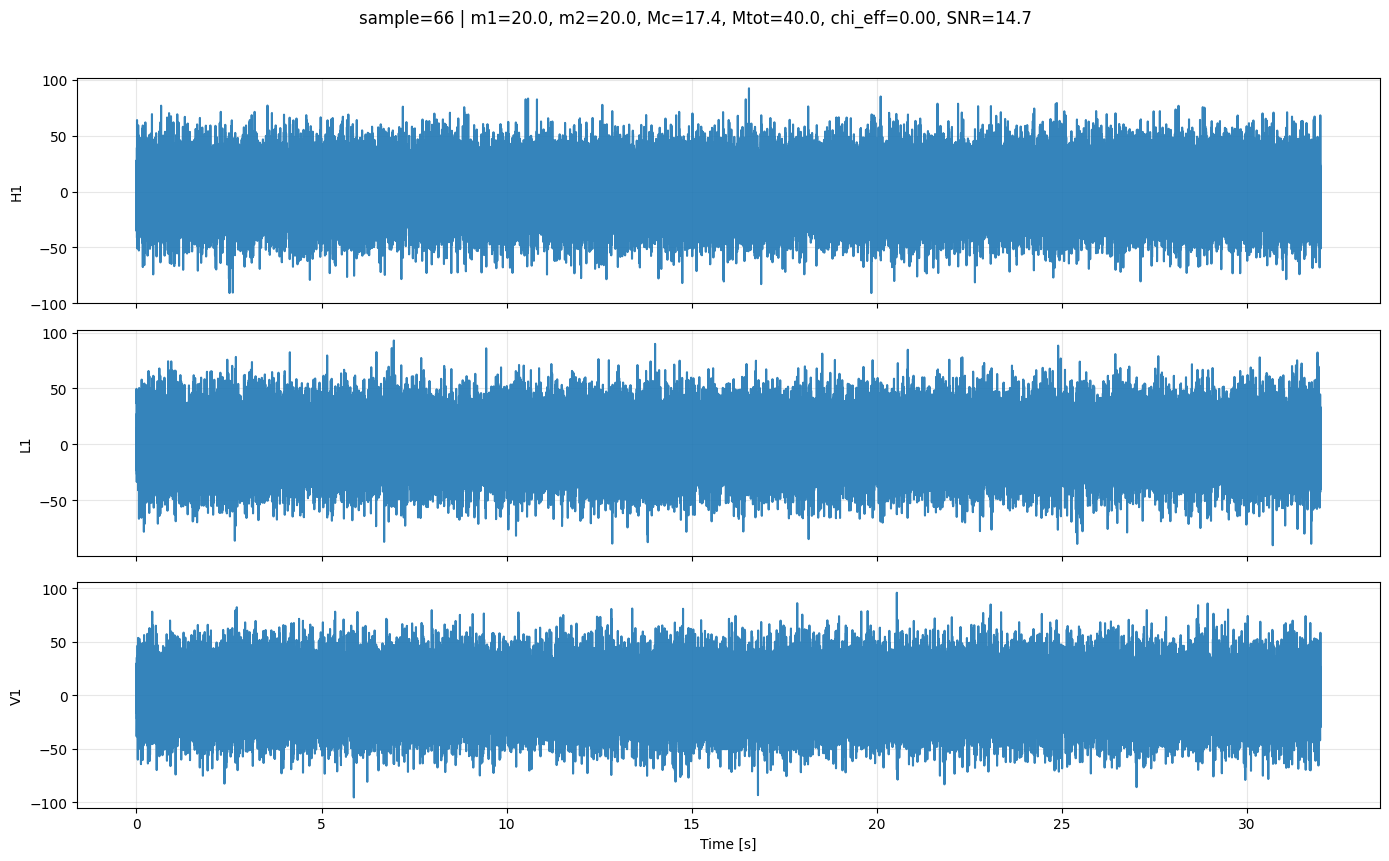

y: [17.41101 40.       0.     ]
params: {'mass_1': np.float32(20.0), 'mass_2': np.float32(20.0), 'chirp_mass': np.float32(17.41101), 'total_mass': np.float32(40.0), 'chi_eff': np.float32(0.0), 'network_snr': np.float32(14.726121)}



In [14]:
rng = np.random.default_rng(123)

random_indices = rng.choice(len(params_df), size=5, replace=False)

for idx in random_indices:
    params, y = plot_sample_from_hdf5(DATASET_PATH, int(idx))
    print("y:", y)
    print("params:", params)
    print()

## 7. Compare low and high chirp-mass examples

If the simulations contain learnable mass information, low-mass and high-mass systems should not look statistically identical.

This is a visual sanity check, not a quantitative proof.

In [15]:
low_mc_indices = params_df.sort_values("chirp_mass").head(3).index.to_numpy()
high_mc_indices = params_df.sort_values("chirp_mass").tail(3).index.to_numpy()

print("Low chirp-mass indices:", low_mc_indices)
print("High chirp-mass indices:", high_mc_indices)

Low chirp-mass indices: [0 1 2]
High chirp-mass indices: [97 98 99]


LOW CHIRP MASS EXAMPLES


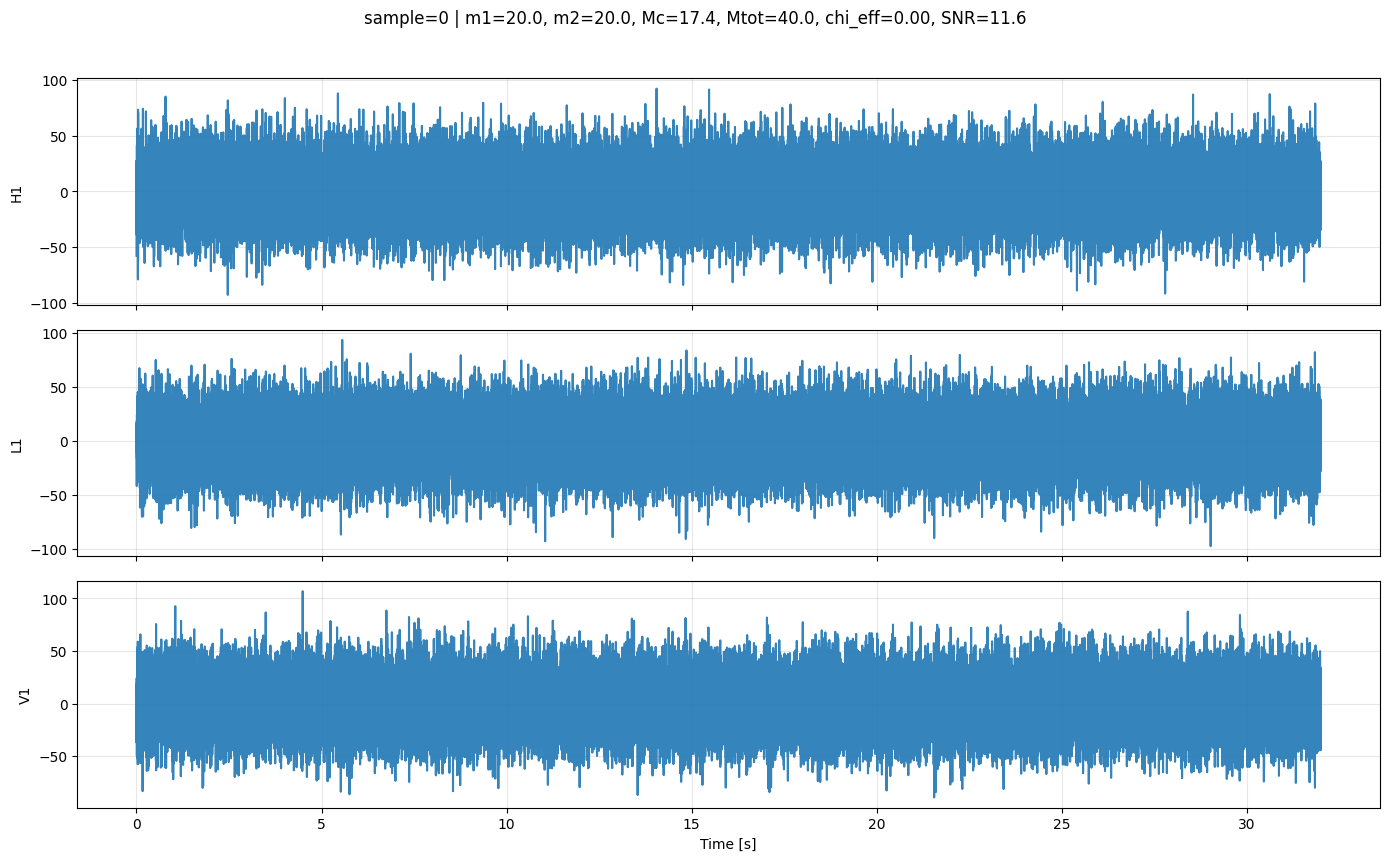

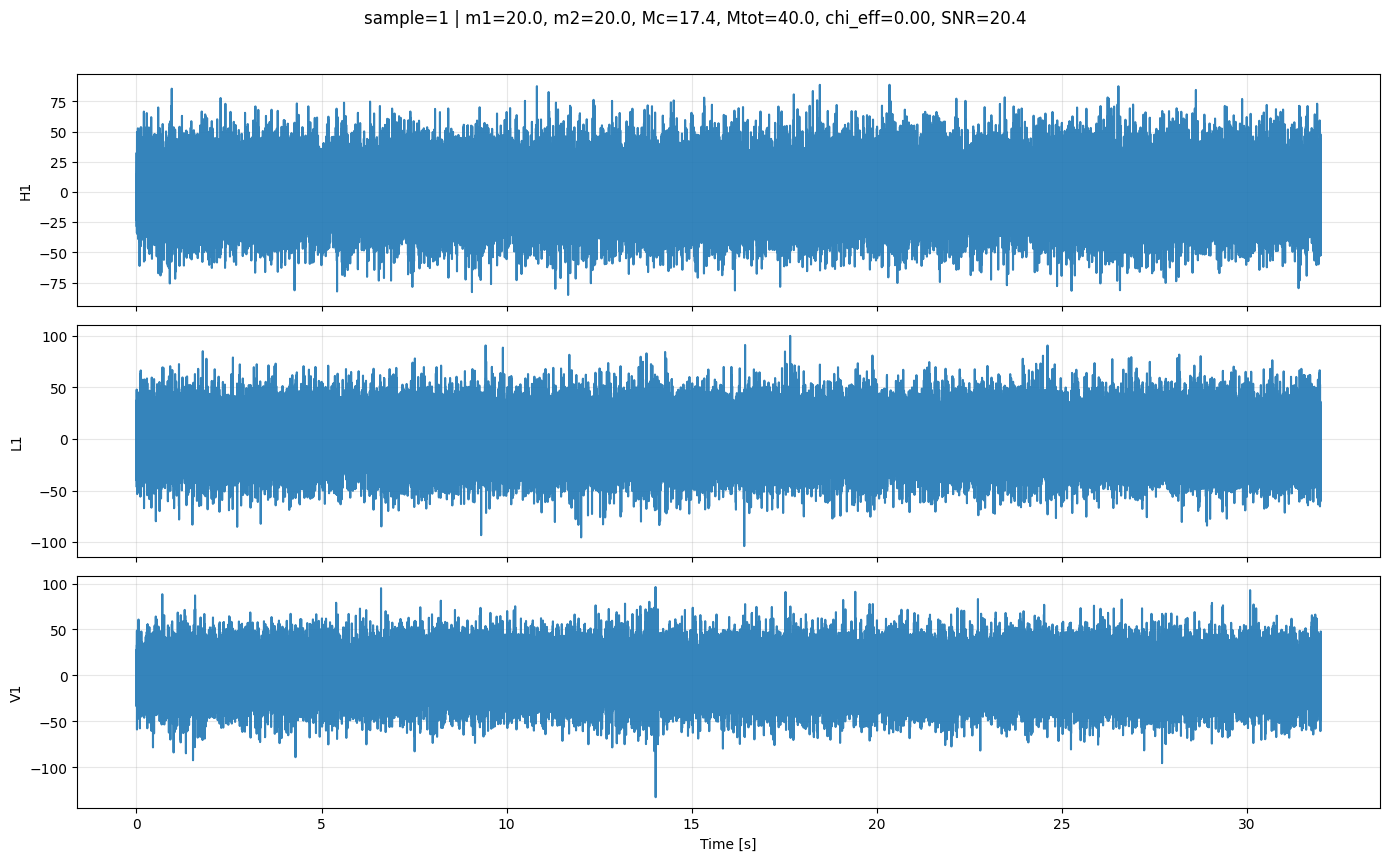

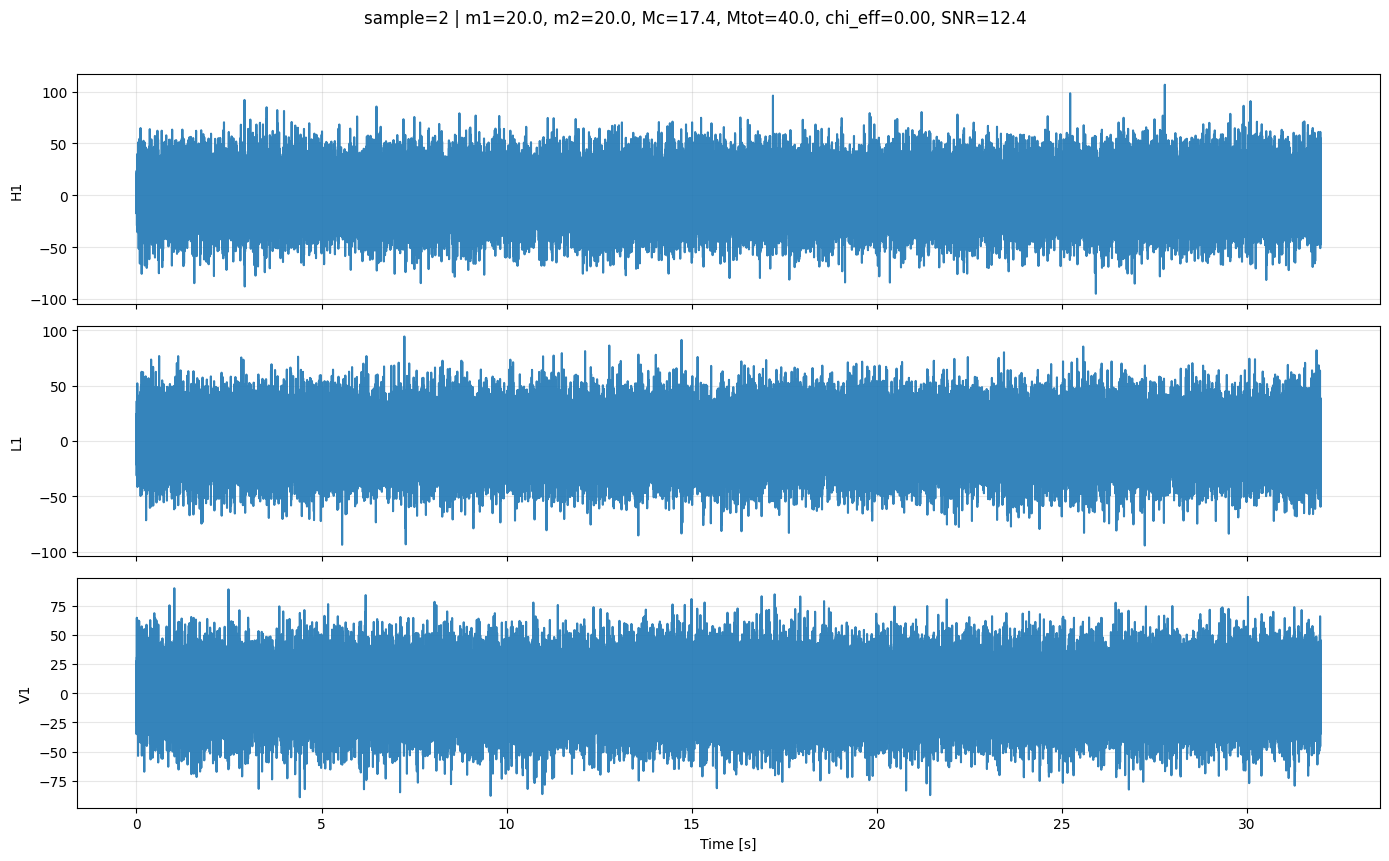

HIGH CHIRP MASS EXAMPLES


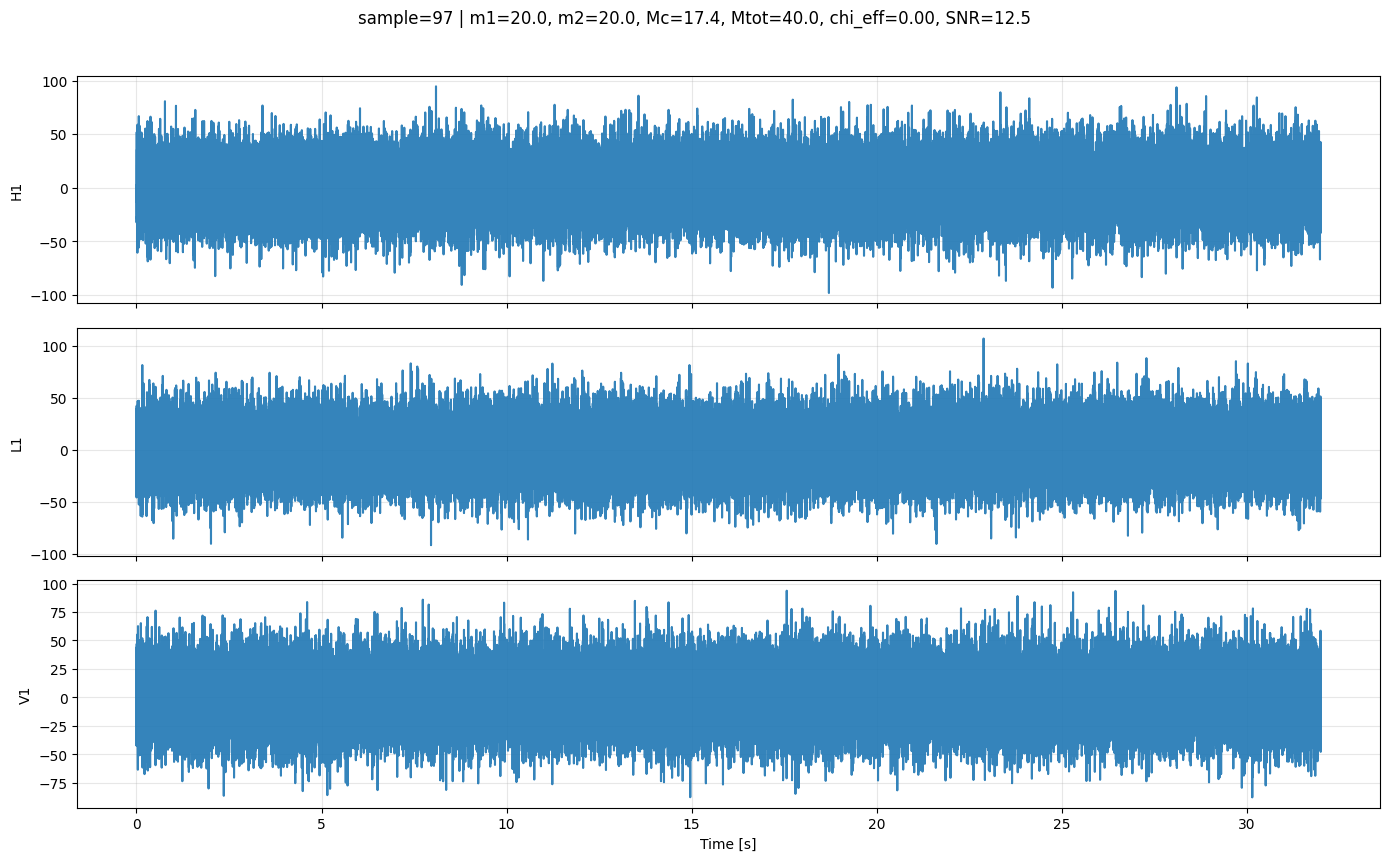

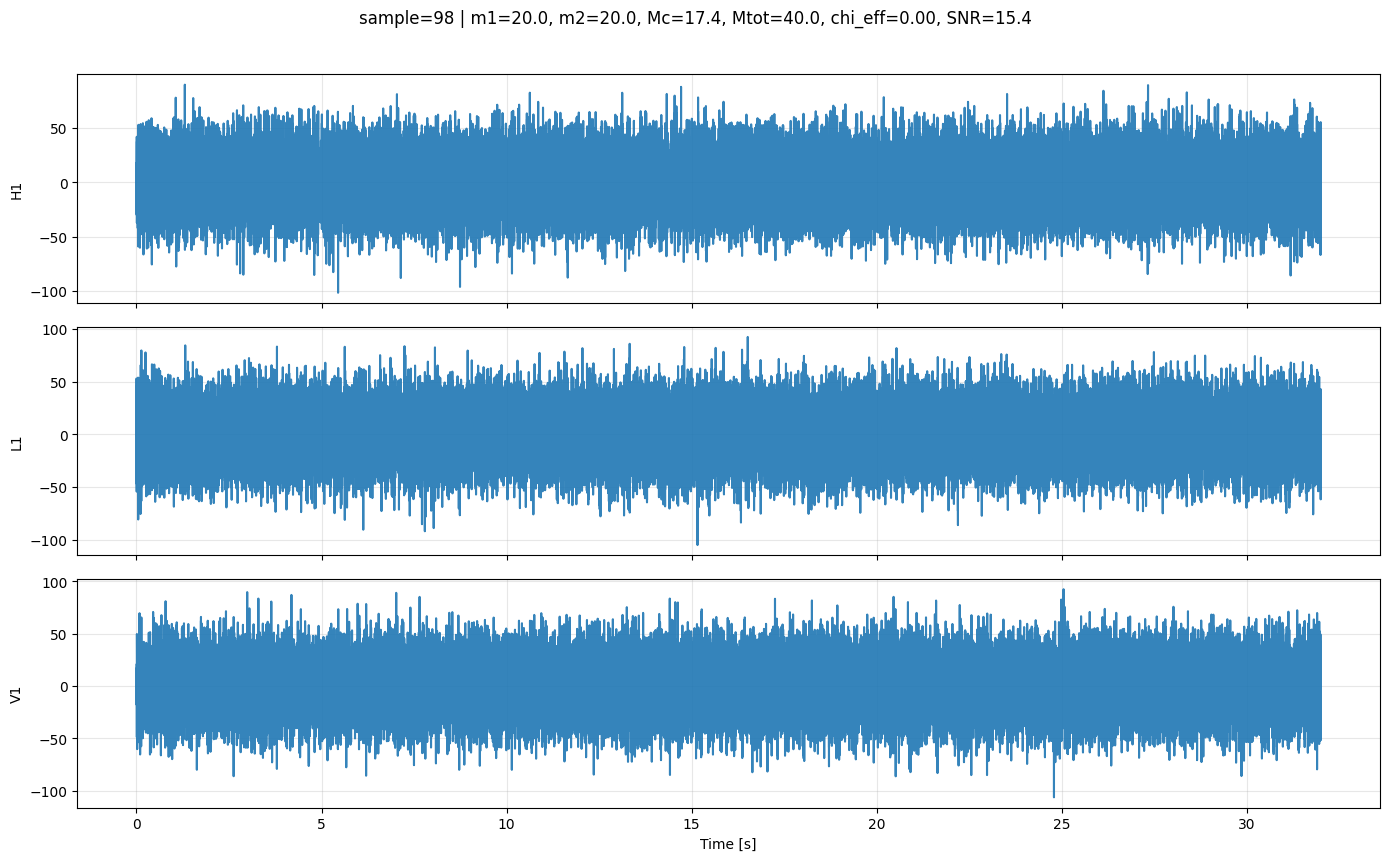

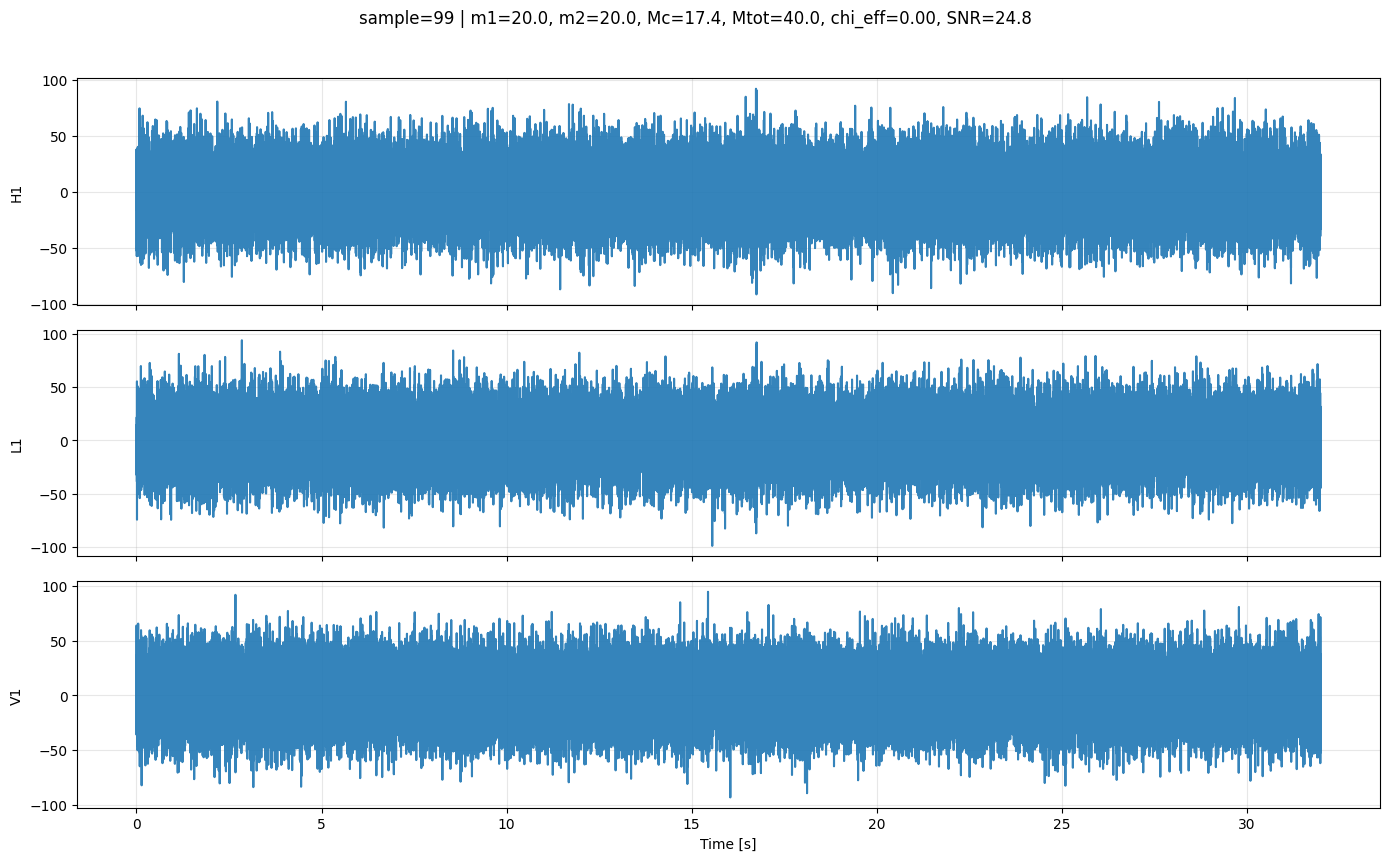

In [16]:
print("LOW CHIRP MASS EXAMPLES")
for idx in low_mc_indices:
    plot_sample_from_hdf5(DATASET_PATH, int(idx))

print("HIGH CHIRP MASS EXAMPLES")
for idx in high_mc_indices:
    plot_sample_from_hdf5(DATASET_PATH, int(idx))

## 8. Cheap baseline models

Before training a CNN, we test whether very simple models can predict anything from crude features.

This is intentionally weak. We do not expect excellent performance. The goal is to check whether there is at least some signal in the data.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [18]:
# Build a small tabular feature set from simple X summary statistics.
features = audit_df[["x_mean", "x_std", "x_max_abs", "x_rms", "network_snr"]].to_numpy()
targets = audit_df[["chirp_mass", "total_mass", "chi_eff"]].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    features,
    targets,
    test_size=0.2,
    random_state=123,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (80, 5)
X_test: (20, 5)
y_train: (80, 3)
y_test: (20, 3)


In [19]:
def evaluate_regression(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    label_names = ["chirp_mass", "total_mass", "chi_eff"]

    rows = []

    for j, label in enumerate(label_names):
        rows.append({
            "model": name,
            "split": "train",
            "label": label,
            "rmse": root_mean_squared_error(y_train[:, j], pred_train[:, j]),
            "mae": mean_absolute_error(y_train[:, j], pred_train[:, j]),
            "r2": r2_score(y_train[:, j], pred_train[:, j]),
        })
        rows.append({
            "model": name,
            "split": "test",
            "label": label,
            "rmse": root_mean_squared_error(y_test[:, j], pred_test[:, j]),
            "mae": mean_absolute_error(y_test[:, j], pred_test[:, j]),
            "r2": r2_score(y_test[:, j], pred_test[:, j]),
        })

    return pd.DataFrame(rows), model


ridge = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0),
)

ridge_results, ridge_model = evaluate_regression(
    "ridge_simple_features",
    ridge,
    X_train,
    y_train,
    X_test,
    y_test,
)

ridge_results

,model,split,label,rmse,mae,r2
0,ridge_simple_features,train,chirp_mass,0.0,0.0,1.0
1,ridge_simple_features,test,chirp_mass,0.0,0.0,1.0
2,ridge_simple_features,train,total_mass,0.0,0.0,1.0
3,ridge_simple_features,test,total_mass,0.0,0.0,1.0
4,ridge_simple_features,train,chi_eff,0.0,0.0,1.0
5,ridge_simple_features,test,chi_eff,0.0,0.0,1.0


In [20]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=123,
    n_jobs=-1,
)

rf_results, rf_model = evaluate_regression(
    "random_forest_simple_features",
    rf,
    X_train,
    y_train,
    X_test,
    y_test,
)

pd.concat([ridge_results, rf_results], ignore_index=True)

,model,split,label,rmse,mae,r2
0,ridge_simple_features,train,chirp_mass,0.0,0.0,1.0
1,ridge_simple_features,test,chirp_mass,0.0,0.0,1.0
2,ridge_simple_features,train,total_mass,0.0,0.0,1.0
3,ridge_simple_features,test,total_mass,0.0,0.0,1.0
4,ridge_simple_features,train,chi_eff,0.0,0.0,1.0
5,ridge_simple_features,test,chi_eff,0.0,0.0,1.0
6,random_forest_simple_features,train,chirp_mass,0.0,0.0,1.0
7,random_forest_simple_features,test,chirp_mass,0.0,0.0,1.0
8,random_forest_simple_features,train,total_mass,0.0,0.0,1.0
9,random_forest_simple_features,test,total_mass,0.0,0.0,1.0


## 9. Tiny raw-array baseline

We now test a deliberately simple baseline using downsampled versions of the actual strain arrays.

This is still not a CNN. It asks a simpler question:

Can a standard regressor extract any information from a compressed representation of `X`?

In [21]:
def load_downsampled_X(h5_path, n_samples=5000, stride=64, seed=123):
    rng = np.random.default_rng(seed)

    with h5py.File(h5_path, "r") as f:
        n_total = f["X"].shape[0]
        idx = rng.choice(n_total, size=min(n_samples, n_total), replace=False)
        idx = np.sort(idx)

        X = f["X"][idx, :, ::stride]
        y = f["y"][idx]

    X_flat = X.reshape(X.shape[0], -1)

    return idx, X_flat, y


idx_ds, X_ds, y_ds = load_downsampled_X(
    DATASET_PATH,
    n_samples=5000,
    stride=64,
    seed=123,
)

print("X_ds:", X_ds.shape)
print("y_ds:", y_ds.shape)

X_ds: (100, 6144)
y_ds: (100, 3)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_ds,
    y_ds,
    test_size=0.2,
    random_state=123,
)

ridge_raw = make_pipeline(
    StandardScaler(),
    Ridge(alpha=10.0),
)

ridge_raw_results, ridge_raw_model = evaluate_regression(
    "ridge_downsampled_raw_X",
    ridge_raw,
    X_train,
    y_train,
    X_test,
    y_test,
)

ridge_raw_results

,model,split,label,rmse,mae,r2
0,ridge_downsampled_raw_X,train,chirp_mass,0.0,0.0,1.0
1,ridge_downsampled_raw_X,test,chirp_mass,0.0,0.0,1.0
2,ridge_downsampled_raw_X,train,total_mass,0.0,0.0,1.0
3,ridge_downsampled_raw_X,test,total_mass,0.0,0.0,1.0
4,ridge_downsampled_raw_X,train,chi_eff,0.0,0.0,1.0
5,ridge_downsampled_raw_X,test,chi_eff,0.0,0.0,1.0


## 10. Tiny CNN overfit test

This is the most important training sanity check.

A neural network should be able to overfit a tiny subset of the data. If it cannot reduce the training loss substantially on 32 or 64 fixed samples, then something is wrong in one of the following:

- data loading;
- label normalization;
- model output;
- loss computation;
- optimizer;
- input scaling;
- target scaling;
- simulation/label correspondence.

This test is not about generalization. It is only about whether the training setup can memorize a tiny dataset.

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [24]:
def load_tiny_dataset(h5_path, n_samples=64):
    with h5py.File(h5_path, "r") as f:
        X = f["X"][:n_samples].astype(np.float32)
        y = f["y"][:n_samples].astype(np.float32)

    # Standardize labels using the tiny training subset itself.
    # This is acceptable here because this is only an overfit sanity check.
    y_mean = y.mean(axis=0, keepdims=True)
    y_std = y.std(axis=0, keepdims=True)
    y_std[y_std == 0] = 1.0

    y_scaled = (y - y_mean) / y_std

    return X, y_scaled, y_mean, y_std


X_tiny, y_tiny, y_tiny_mean, y_tiny_std = load_tiny_dataset(DATASET_PATH, n_samples=100)

print("X_tiny:", X_tiny.shape)
print("y_tiny:", y_tiny.shape)
print("X mean/std:", X_tiny.mean(), X_tiny.std())
print("y scaled mean/std:", y_tiny.mean(axis=0), y_tiny.std(axis=0))

X_tiny: (100, 3, 131072)
y_tiny: (100, 3)
X mean/std: 3.6489764e-05 21.837631
y scaled mean/std: [0. 0. 0.] [0. 0. 0.]


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [26]:
class TinyCNN(nn.Module):
    def __init__(self, n_outputs=3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(3, 16, kernel_size=16, stride=4, padding=4),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=16, stride=4, padding=4),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=16, stride=4, padding=4),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(8),
            nn.Flatten(),
            nn.Linear(64 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, n_outputs),
        )

    def forward(self, x):
        return self.net(x)

In [27]:
torch.manual_seed(123)

dataset = TensorDataset(
    torch.tensor(X_tiny, dtype=torch.float32),
    torch.tensor(y_tiny, dtype=torch.float32),
)

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
)

model = TinyCNN(n_outputs=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

loss_history = []

for epoch in range(1, 501):
    model.train()
    epoch_losses = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    mean_loss = float(np.mean(epoch_losses))
    loss_history.append(mean_loss)

    if epoch == 1 or epoch % 50 == 0:
        print(f"epoch {epoch:04d} | train_loss = {mean_loss:.6f}")

epoch 0001 | train_loss = 0.129041
epoch 0050 | train_loss = 0.000003
epoch 0100 | train_loss = 0.000002
epoch 0150 | train_loss = 0.000002
epoch 0200 | train_loss = 0.000001
epoch 0250 | train_loss = 0.000001
epoch 0300 | train_loss = 0.000000
epoch 0350 | train_loss = 0.000000
epoch 0400 | train_loss = 0.000000
epoch 0450 | train_loss = 0.000000
epoch 0500 | train_loss = 0.000000


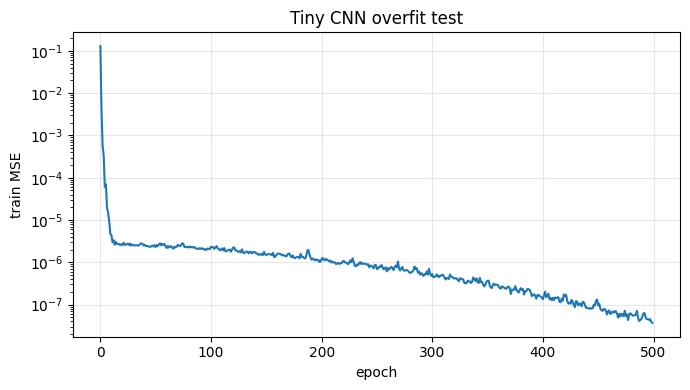

In [28]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("train MSE")
plt.title("Tiny CNN overfit test")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
model.eval()

with torch.no_grad():
    pred_scaled = model(torch.tensor(X_tiny, dtype=torch.float32).to(device)).cpu().numpy()

pred_physical = pred_scaled * y_tiny_std + y_tiny_mean
y_physical = y_tiny * y_tiny_std + y_tiny_mean

label_names = ["chirp_mass", "total_mass", "chi_eff"]

for j, label in enumerate(label_names):
    rmse = np.sqrt(np.mean((pred_physical[:, j] - y_physical[:, j]) ** 2))
    mae = np.mean(np.abs(pred_physical[:, j] - y_physical[:, j]))

    print(label)
    print("  RMSE:", rmse)
    print("  MAE:", mae)

chirp_mass
  RMSE: 0.00027652367
  MAE: 0.00023866653
total_mass
  RMSE: 0.00018006786
  MAE: 0.00014240266
chi_eff
  RMSE: 0.00019912202
  MAE: 0.00016071953


## 11. Input scaling check

The current processed input has a global standard deviation around 20 in the first check.

That may be acceptable, but very large or inconsistent input scales can make training harder. Here we test whether per-sample or global input normalization changes the tiny overfit result.

In [30]:
def normalize_per_sample(X, eps=1e-8):
    mean = X.mean(axis=(1, 2), keepdims=True)
    std = X.std(axis=(1, 2), keepdims=True)
    return (X - mean) / (std + eps)


X_tiny_norm = normalize_per_sample(X_tiny)

print("before:", X_tiny.mean(), X_tiny.std())
print("after:", X_tiny_norm.mean(), X_tiny_norm.std())

before: 3.6489764e-05 21.837631
after: -7.3984363e-10 1.0000002


In [31]:
torch.manual_seed(123)

dataset_norm = TensorDataset(
    torch.tensor(X_tiny_norm, dtype=torch.float32),
    torch.tensor(y_tiny, dtype=torch.float32),
)

loader_norm = DataLoader(
    dataset_norm,
    batch_size=16,
    shuffle=True,
)

model_norm = TinyCNN(n_outputs=3).to(device)
optimizer = torch.optim.Adam(model_norm.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

loss_history_norm = []

for epoch in range(1, 501):
    model_norm.train()
    epoch_losses = []

    for xb, yb in loader_norm:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model_norm(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    mean_loss = float(np.mean(epoch_losses))
    loss_history_norm.append(mean_loss)

    if epoch == 1 or epoch % 50 == 0:
        print(f"epoch {epoch:04d} | train_loss = {mean_loss:.6f}")

epoch 0001 | train_loss = 0.000829
epoch 0050 | train_loss = 0.000000
epoch 0100 | train_loss = 0.000000
epoch 0150 | train_loss = 0.000000
epoch 0200 | train_loss = 0.000000
epoch 0250 | train_loss = 0.000000
epoch 0300 | train_loss = 0.000000
epoch 0350 | train_loss = 0.000000
epoch 0400 | train_loss = 0.000000
epoch 0450 | train_loss = 0.000000
epoch 0500 | train_loss = 0.000000


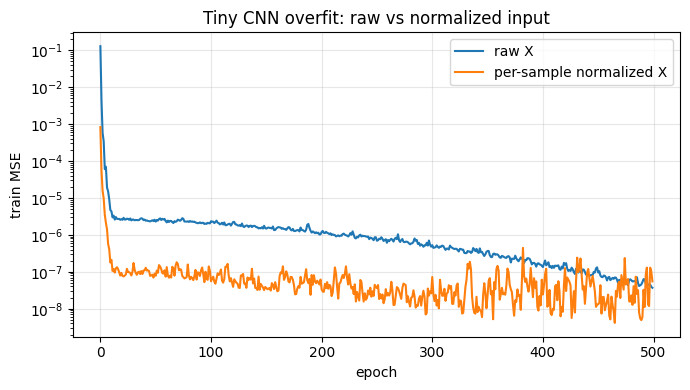

In [32]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, label="raw X")
plt.plot(loss_history_norm, label="per-sample normalized X")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("train MSE")
plt.title("Tiny CNN overfit: raw vs normalized input")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Audit summary

At this point we should be able to answer:

1. Is the HDF5 file internally consistent?
2. Do labels match the saved physical parameters?
3. Are SNRs in the expected range?
4. Do simple signal statistics vary across samples?
5. Are any simple features correlated with physical parameters?
6. Can a weak baseline learn anything?
7. Can a tiny CNN overfit a tiny subset?

If the answer to 6 or 7 is no, we should not generate additional large datasets yet.